# Corpus Masterclass 3a: Collocations, Keyword Windows, Dispersion, Decade Networks

Five techniques that look inside the corpus rather than summarising it whole: frequent two-word phrases, the context around a keyword, where a word falls within a speech, what is distinctive about that context, and how category co-occurrence shifts decade by decade.

## Today's goal

1. Find the most frequent bigrams in the corpus.
2. Replace selected multi-word phrases with single tokens.
3. Capture the keyword windows around `atom`, `nuclear`, `nuke`.
4. Rank what is distinctive inside those windows by keyness.
5. Draw lexical-dispersion plots for a word across the corpus.
6. Build a category co-occurrence network for each decade with a function and a loop.

In [1]:
# Libraries used throughout the notebook.
import sotu
import pandas
import numpy
import re
import liwc
import matplotlib.pyplot as plt
import nltk.collocations
import scipy.stats
import networkx
from corpus_tools import liwcalike

print('Libraries imported.')

Libraries imported.


In [2]:
# Load the corpus.
df = sotu.load()
print(f'{len(df)} speeches, {df["year"].min()} to {df["year"].max()}.')

237 speeches, 1790 to 2026.


In [3]:
# Collocations need every token in order. Tokenise each speech and collect the tokens
# into one flat list. Keep the original capitalisation: the bigram step below selects
# capitalised words, which are mostly proper nouns. extend adds the items of one list
# to the end of another.
all_tokens = []
for text in df['text']:
    all_tokens.extend(re.findall(r'\w+', text))

print(f'{len(all_tokens):,} tokens across the corpus.')

2,007,679 tokens across the corpus.


In [4]:
# A bigram is a pair of consecutive tokens. We want phrases, not the most frequent word
# pairs, which would just be 'of the' and 'in the'. Two steps get there. First, keep only
# bigrams whose words both start with a capital letter and run two letters or more, which
# skips stopwords, initials, and the lone pronoun I, surfacing proper-noun phrases. Second,
# rank by a collocation statistic rather than raw count: the likelihood ratio is high when
# two words occur together far more often than chance.
def not_proper(word):
    return len(word) < 2 or not word[:1].isupper()

finder = nltk.collocations.BigramCollocationFinder.from_words(all_tokens)
finder.apply_word_filter(not_proper)
finder.apply_freq_filter(100)

measures = nltk.collocations.BigramAssocMeasures()
scored = finder.score_ngrams(measures.likelihood_ratio)
for (first, second), score in scored[:20]:
    print(f'{score:10.1f}  {first} {second}')

   57998.7  United States
    8877.9  Great Britain
    3010.6  Postmaster General
    2835.5  Federal Government
    2697.3  New York
    2663.7  Social Security
    2656.7  Post Office
    2633.3  Supreme Court
    2238.1  Middle East
    2133.9  Soviet Union
    1922.6  Vice President
    1728.0  United Nations
    1626.5  White House
    1567.0  Attorney General
    1526.9  World War
    1331.6  Office Department
    1273.9  Central America
    1121.0  General Government
     973.5  National Government
     837.4  British Government


In [5]:
# A replacement dictionary maps a two-token phrase to a single token. Treating 'united
# states' as one token keeps it from scattering across two unrelated counts.
replacements = {
    ('united', 'states'): 'unitedstates',
    ('federal', 'government'): 'federalgovernment',
    ('soviet', 'union'): 'sovietunion',
    ('world', 'war'): 'worldwar',
    ('united', 'nations'): 'unitednations',
    ('central', 'america'): 'centralamerica',
    ('great', 'britain'): 'greatbritain',
    ('supreme', 'court'): 'supremecourt',
}
print(f'{len(replacements)} replacement rules.')

8 replacement rules.


In [6]:
# apply_replacements walks a token list. When the current and next token match a rule,
# it emits the single replacement token and skips ahead by two. A while loop is used
# because we sometimes advance by one position and sometimes by two.
def apply_replacements(tokens):
    output = []
    index = 0
    while index < len(tokens):
        if index + 1 < len(tokens):
            pair = (tokens[index], tokens[index + 1])
        else:
            pair = None
        if pair is not None and pair in replacements:
            output.append(replacements[pair])
            index = index + 2
        else:
            output.append(tokens[index])
            index = index + 1
    return output

sample = ['the', 'united', 'states', 'and', 'the', 'soviet', 'union']
print(apply_replacements(sample))

['the', 'unitedstates', 'and', 'the', 'sovietunion']


In [7]:
# Re-tokenise every speech with phrase replacement applied. Keep one token list per
# speech so we can locate words within their own document later.
speech_tokens = []
for text in df['text']:
    speech_tokens.append(apply_replacements(re.findall(r'\w+', text.lower())))

print(f'{len(speech_tokens)} speeches re-tokenised.')

237 speeches re-tokenised.


In [8]:
# A keyword window is the run of tokens on either side of a target word. matches_pattern
# returns True if a token starts with any of the given prefixes, so 'atom' also catches
# 'atomic'.
def matches_pattern(token, patterns):
    for pattern in patterns:
        if token.startswith(pattern):
            return True
    return False

nuke_patterns = ['atom', 'nuclear', 'nuke']
for word in ['atom', 'atomic', 'nuclear', 'apple']:
    print(f'{word}: {matches_pattern(word, nuke_patterns)}')

atom: True
atomic: True
nuclear: True
apple: False


In [9]:
# split_inside_outside walks one speech. For each matching token it records the window
# of tokens around it and marks those positions. Everything unmarked is the 'outside'.
def split_inside_outside(tokens, patterns, window=10):
    near_match = [False] * len(tokens)
    inside_windows = []
    for index, token in enumerate(tokens):
        if matches_pattern(token, patterns):
            start = max(0, index - window)
            end = min(len(tokens), index + window + 1)
            inside_windows.append(tokens[start:end])
            for marker in range(start, end):
                near_match[marker] = True
    outside_tokens = []
    for index, token in enumerate(tokens):
        if not near_match[index]:
            outside_tokens.append(token)
    return inside_windows, outside_tokens

In [10]:
# Apply to every speech and gather all inside-window tokens and all outside tokens. Drop
# the keyword itself from the inside windows: it sits in every window by definition, so
# leaving it in would just rank the search word at the top of its own keyness. We want
# the words around it.
all_inside = []
all_outside = []
for tokens in speech_tokens:
    inside, outside = split_inside_outside(tokens, nuke_patterns, window=10)
    for window_tokens in inside:
        for token in window_tokens:
            if matches_pattern(token, nuke_patterns):
                continue
            all_inside.append(token)
    all_outside.extend(outside)

print(f'Inside: {len(all_inside):,} tokens. Outside: {len(all_outside):,} tokens.')

Inside: 9,386 tokens. Outside: 1,992,208 tokens.


In [11]:
# Count each word in both groups. dict.get(word, 0) returns 0 when the word is not yet
# a key.
inside_counts = {}
for token in all_inside:
    inside_counts[token] = inside_counts.get(token, 0) + 1
outside_counts = {}
for token in all_outside:
    outside_counts[token] = outside_counts.get(token, 0) + 1

print(f'Distinct words inside: {len(inside_counts):,}.')

Distinct words inside: 1,896.


In [12]:
# Keyness compares a word's inside frequency against its outside frequency. The
# chi-squared statistic on a 2x2 contingency table is large when a word is much more
# common inside the windows than outside.
total_inside = len(all_inside)
total_outside = len(all_outside)

keyness = []
for word, inside_count in inside_counts.items():
    if inside_count < 5:
        continue
    outside_count = outside_counts.get(word, 0)
    table = [
        [inside_count, total_inside - inside_count],
        [outside_count, total_outside - outside_count],
    ]
    statistic = scipy.stats.chi2_contingency(table).statistic
    keyness.append((word, statistic, inside_count, outside_count))

print(f'Keyness computed for {len(keyness):,} words.')

Keyness computed for 314 words.


In [13]:
# Sort by the statistic, highest first, and show the top 20. sort_key returns the
# statistic from each tuple; passing it to sorted ranks by that value.
def sort_key(entry):
    return entry[1]

ranked = sorted(keyness, key=sort_key, reverse=True)
print('Top 20 keywords inside the nuclear windows:')
for word, statistic, inside_count, outside_count in ranked[:20]:
    print(f'  {word:18s}  chi-squared {statistic:8.1f}  inside {inside_count:4d}  outside {outside_count:5d}')

Top 20 keywords inside the nuclear windows:
  weapons             chi-squared   9259.6  inside  114  outside   177
  proliferation       chi-squared   4179.7  inside   31  outside    16
  ban                 chi-squared   1400.9  inside   19  outside    32
  evaluation          chi-squared   1291.3  inside   11  outside     7
  testing             chi-squared   1222.4  inside   15  outside    21
  iran                chi-squared    998.3  inside   23  outside    81
  infce               chi-squared    914.9  inside    6  outside     1
  stockpile           chi-squared    893.6  inside    9  outside     8
  cycle               chi-squared    887.6  inside   11  outside    15
  energy              chi-squared    884.8  inside   62  outside   745
  reactors            chi-squared    637.1  inside    6  outside     4
  warheads            chi-squared    637.1  inside    6  outside     4
  arms                chi-squared    630.7  inside   32  outside   275
  fuel                chi-squared

In [14]:
# Restrict the dispersion analysis to speeches from 1908 onward, when nuclear vocabulary
# enters the language.
modern_indices = []
for original_index, year in enumerate(df['year']):
    if year >= 1908:
        modern_indices.append(original_index)

print(f'{len(modern_indices)} speeches from 1908 onward.')

118 speeches from 1908 onward.


In [15]:
# A lexical-dispersion plot shows where in each speech a word appears. Only speeches
# that use the word are shown. The x-axis is the absolute token position. Each grey
# bar is the length of one speech, and each black mark is one occurrence.
def dispersion_plot(prefix, title):
    row_labels = []
    row_lengths = []
    row_positions = []
    for original_index in modern_indices:
        tokens = speech_tokens[original_index]
        positions = []
        for token_index, token in enumerate(tokens):
            if token.startswith(prefix):
                positions.append(token_index)
        if len(positions) == 0:
            continue
        row_labels.append(f'{df.iloc[original_index]["year"]} {df.iloc[original_index]["president"]}')
        row_lengths.append(len(tokens))
        row_positions.append(positions)
    plt.figure(figsize=(11, max(2.5, 0.30 * len(row_labels))))
    for plot_row in range(len(row_labels)):
        plt.hlines(plot_row, 0, row_lengths[plot_row], color='lightgray', linewidth=6, zorder=1)
        marks = row_positions[plot_row]
        plt.scatter(marks, [plot_row] * len(marks), marker='|', s=120, color='black', zorder=2)
    plt.yticks(range(len(row_labels)), row_labels, fontsize=7)
    plt.xlabel('Token index')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

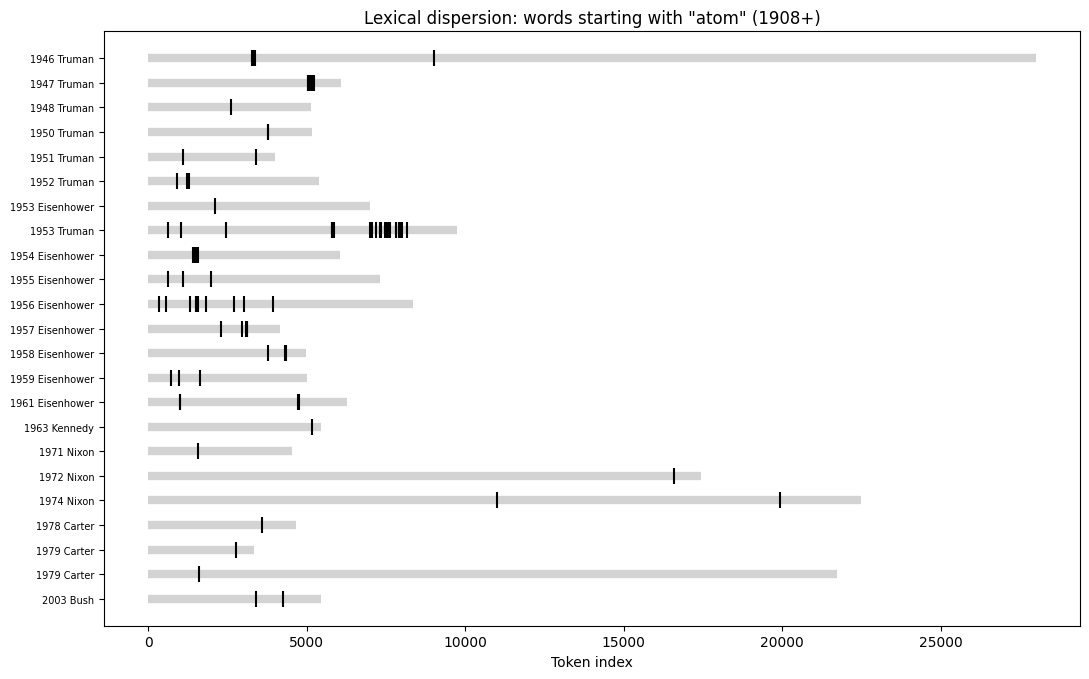

In [16]:
# Dispersion of words starting with 'atom'.
dispersion_plot('atom', 'Lexical dispersion: words starting with "atom" (1908+)')

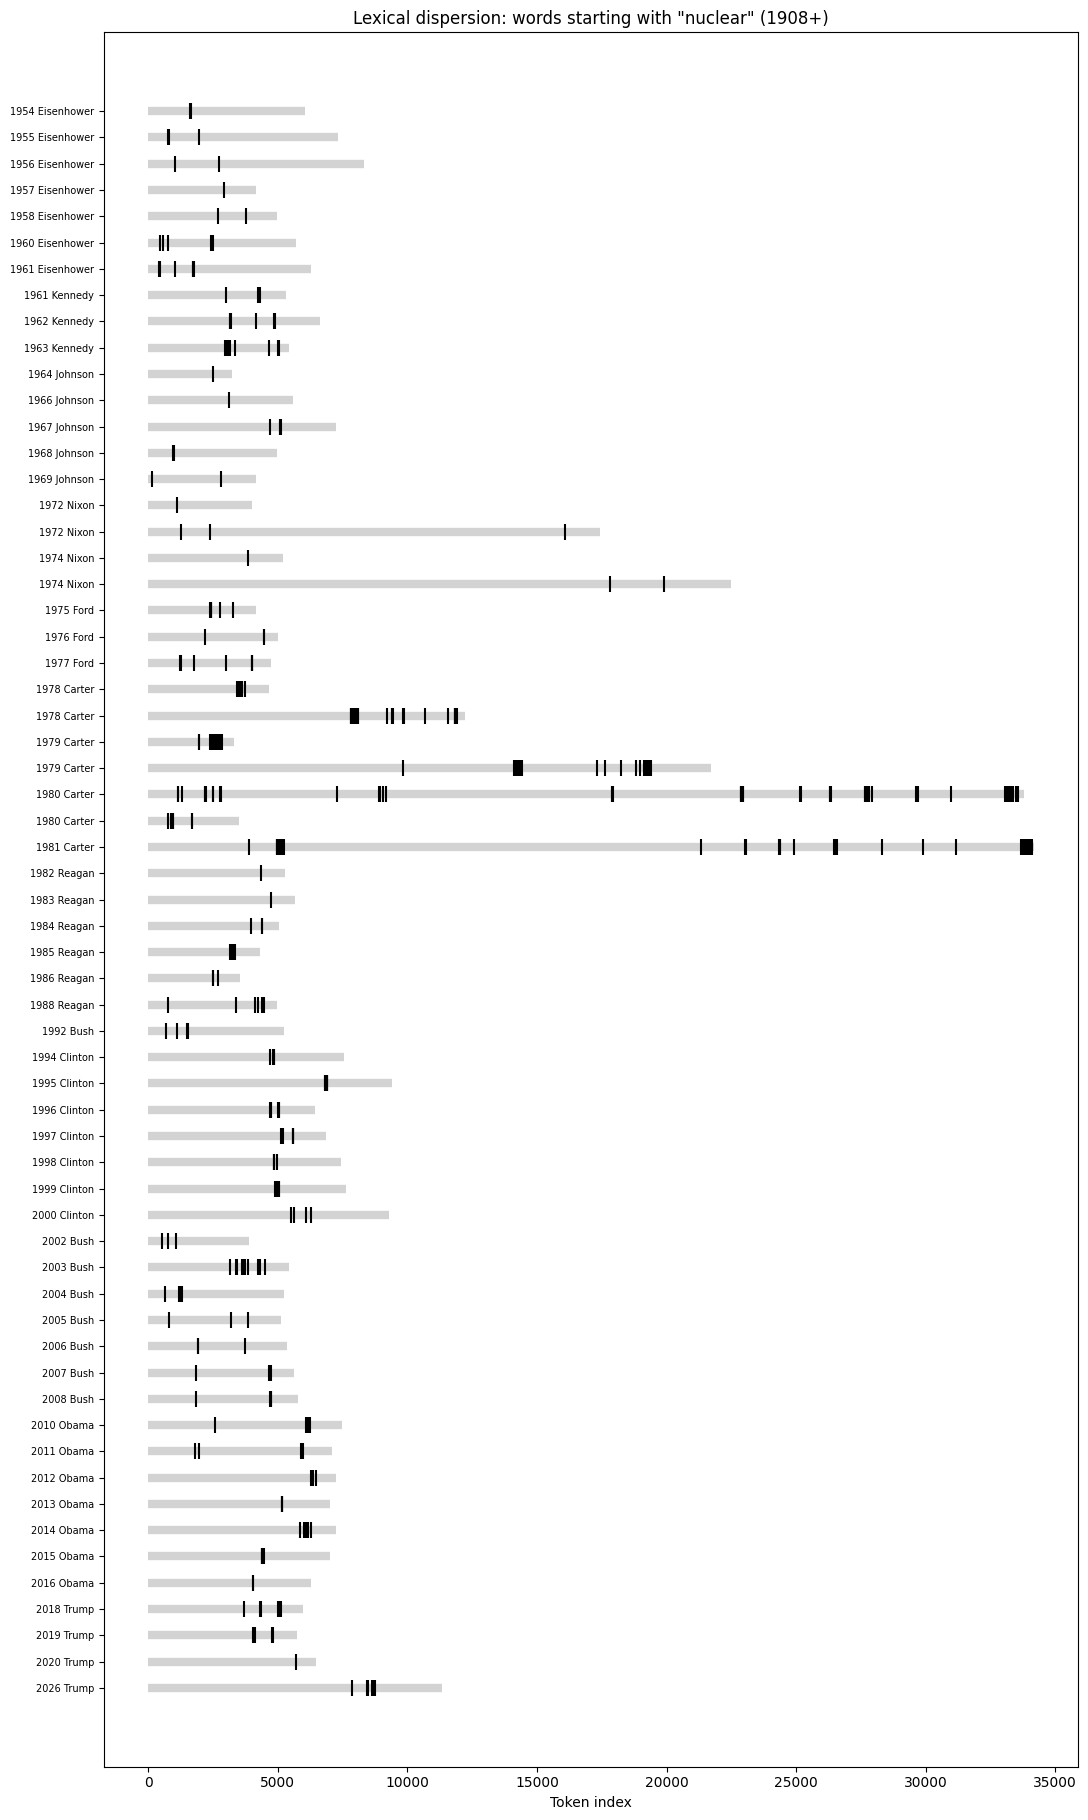

In [17]:
# Dispersion of words starting with 'nuclear'.
dispersion_plot('nuclear', 'Lexical dispersion: words starting with "nuclear" (1908+)')

In [18]:
# The nuke dictionary has many categories (nuke, weapon, energy, suppliers, ...); the
# genuinely nuclear words live in the 'nuke' category. liwcalike reports every category as
# a percentage, and we plot the 'nuke' one.
_, nuke_categories = liwc.load_token_parser('dictionaries/nuke.dic')
print(f'{len(nuke_categories)} categories. nuke in them: {"nuke" in nuke_categories}')

30 categories. nuke in them: True


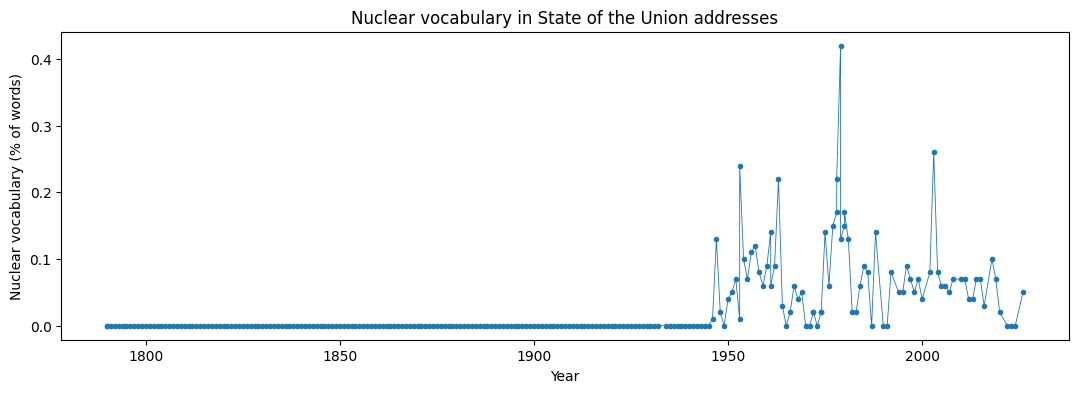

In [19]:
# liwcalike with the nuke dictionary gives the 'nuke' category as a percentage of each
# speech's words. Plot that percentage over time.
nuke_docnames = []
for _, speech in df.iterrows():
    nuke_docnames.append(f"{speech['president']}_{speech['year']}")

nuke_df = liwcalike(list(df['text']), nuke_docnames, 'dictionaries/nuke.dic')
nuke_df['year'] = list(df['year'])
nuke_df = nuke_df.sort_values('year')
plt.figure(figsize=(13, 4))
plt.plot(nuke_df['year'], nuke_df['nuke'], marker='o', markersize=3, linewidth=0.6)
plt.xlabel('Year')
plt.ylabel('Nuclear vocabulary (% of words)')
plt.title('Nuclear vocabulary in State of the Union addresses')
plt.show()

In [20]:
# The decade networks reuse the nuke liwcalike table built above. nuke_df already holds
# every speech's nuclear-category percentages and its year, so no new feature matrix is
# needed: subset a decade and keep the category columns.
nuke_df[['year'] + nuke_categories].head(3)

,year,nuke,weapon,proliferation,ban,energy,intermediate-range,reactor,arms,nonproliferation,...,tlatelolco,stockpile,warheads,fuel,korea,spread,missiles,biological,cycle,repository
0,1790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1791,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
# decade_network builds the co-occurrence network for one decade from the nuclear-category
# percentages. Subset the decade, form the adjacency, drop self-loops, keep the strongest
# links, and drop any category left isolated, so a dense thirty-category matrix renders as
# a readable graph. A fresh force-directed layout is computed for each decade: the 2025 R
# code reused one decade's layout for every plot, which we do not.
# The display numbers below are tuned for legibility, not analysis. Node area scales with
# how often a category appears in the decade, relative to that decade's busiest category;
# faint thin edges are weak co-occurrences.
def decade_network(decade_start, top_edges=40):
    decade_end = decade_start + 9
    mask = (nuke_df['year'] >= decade_start) & (nuke_df['year'] <= decade_end)
    subset = nuke_df[mask][nuke_categories]
    if len(subset) == 0:
        print(f'No speeches in the {decade_start}s.')
        return
    adjacency = subset.to_numpy().T @ subset.to_numpy()
    graph = networkx.from_numpy_array(adjacency)
    relabelling = {}
    for node_index, name in enumerate(nuke_categories):
        relabelling[node_index] = name
    graph = networkx.relabel_nodes(graph, relabelling)
    graph.remove_edges_from(list(networkx.selfloop_edges(graph)))
    # Rank the edges by weight, keep the strongest, and drop categories left with none.
    ranked_edges = []
    for u, v in graph.edges():
        ranked_edges.append((graph[u][v]['weight'], u, v))
    def by_weight(item):
        return item[0]
    ranked_edges = sorted(ranked_edges, key=by_weight, reverse=True)
    for weight, u, v in ranked_edges[top_edges:]:
        graph.remove_edge(u, v)
    graph.remove_nodes_from(list(networkx.isolates(graph)))
    if graph.number_of_nodes() == 0:
        print(f'No nuclear-category co-occurrences in the {decade_start}s.')
        return
    weights = []
    for u, v in graph.edges():
        weights.append(graph[u][v]['weight'])
    largest = max(weights) if weights else 1
    widths = []
    edge_colors = []
    for weight in weights:
        widths.append(weight / largest * 5)
        shade = 0.85 - 0.7 * (weight / largest)
        edge_colors.append((shade, shade, shade))
    category_totals = subset.sum(axis=0)
    biggest = category_totals.max() if category_totals.max() > 0 else 1
    node_sizes = []
    for node in graph.nodes():
        node_sizes.append(300 + category_totals[node] / biggest * 1900)
    plt.figure(figsize=(9, 8))
    networkx.draw(
        graph,
        pos=networkx.spring_layout(graph, seed=42, weight='weight'),
        with_labels=True,
        node_color='lightyellow',
        node_size=node_sizes,
        edge_color=edge_colors,
        width=widths,
        font_size=8,
    )
    plt.title(f'Nuclear vocabulary co-occurrence, the {decade_start}s ({len(subset)} speeches)')
    plt.show()

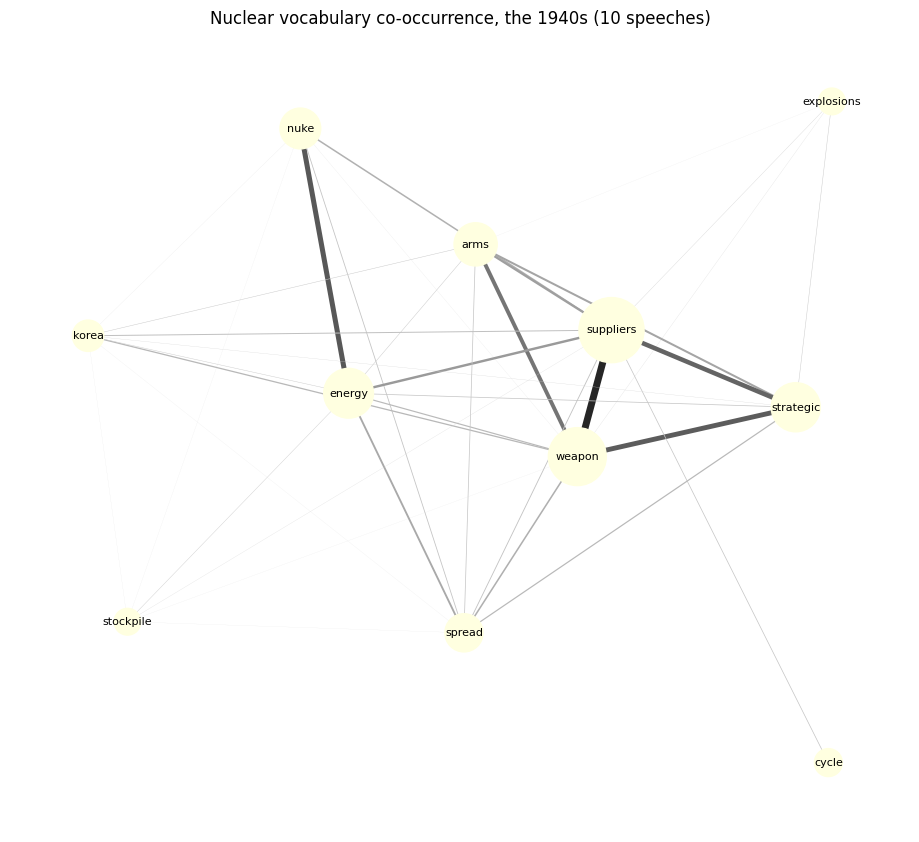

In [22]:
# One worked decade.
decade_network(1940)

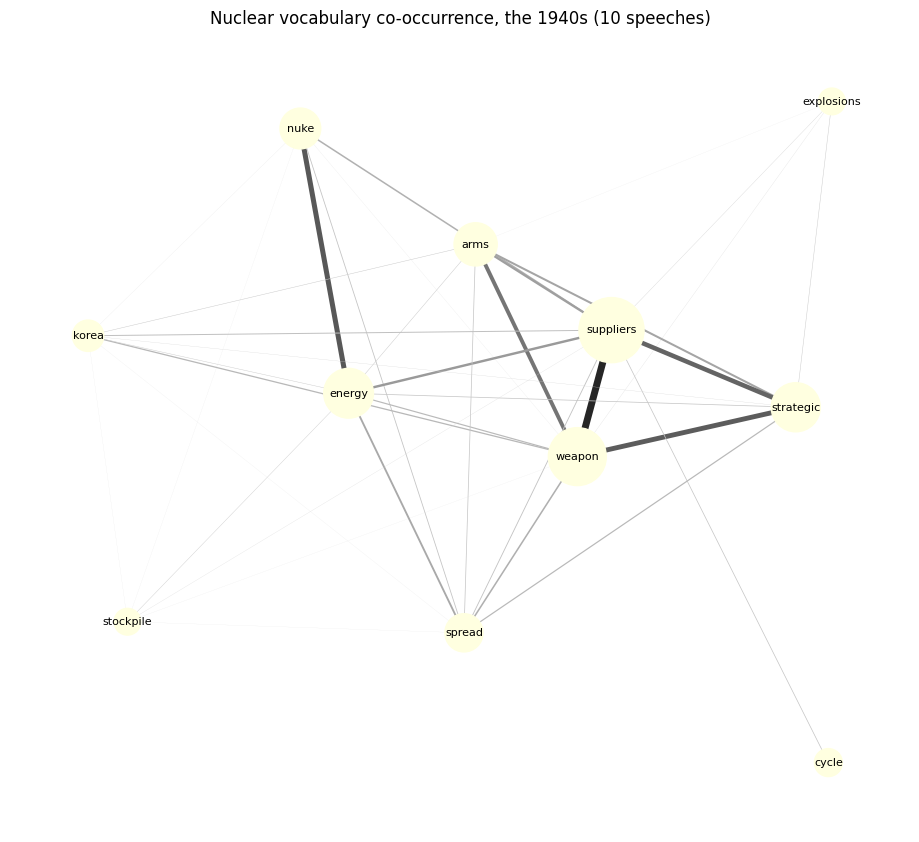

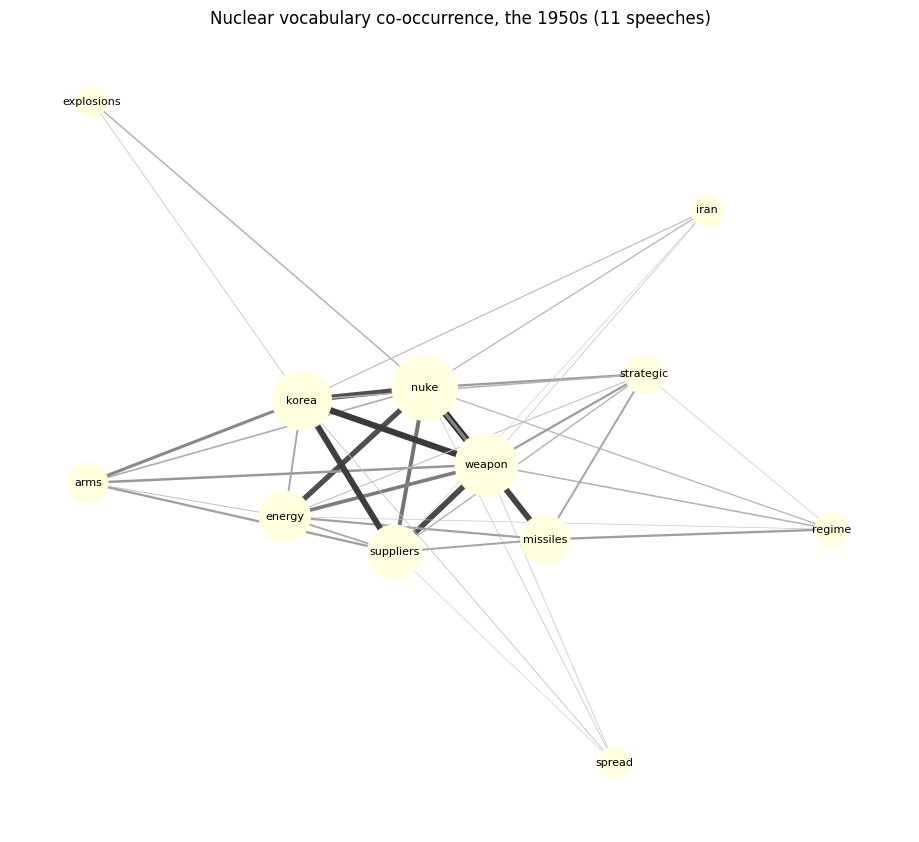

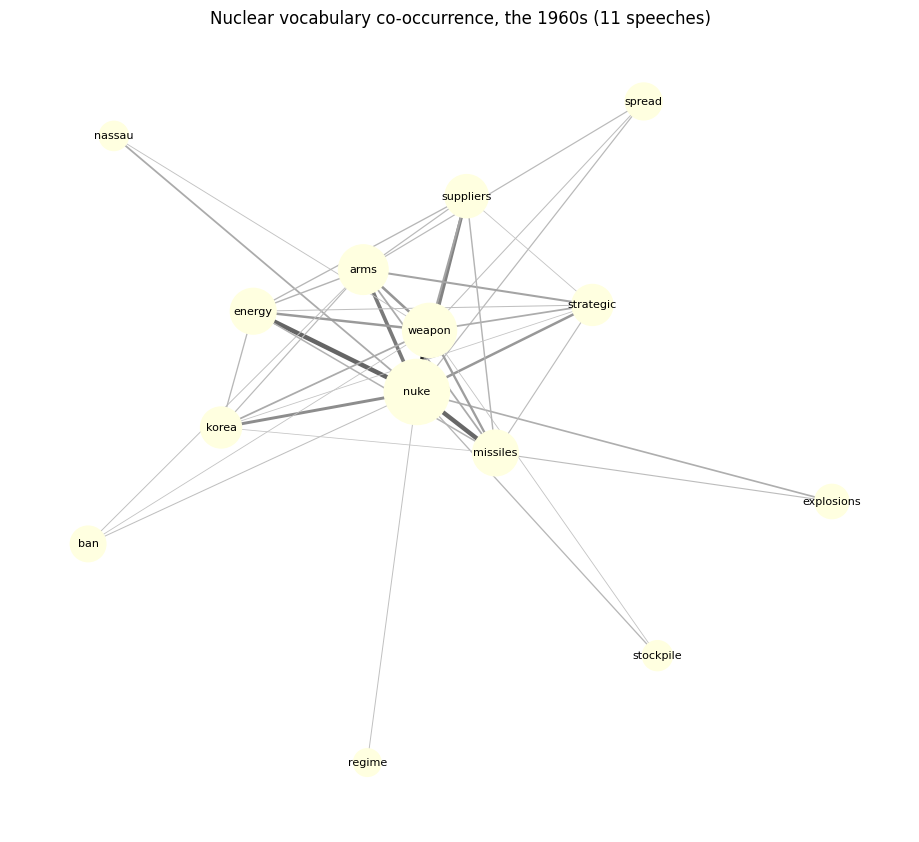

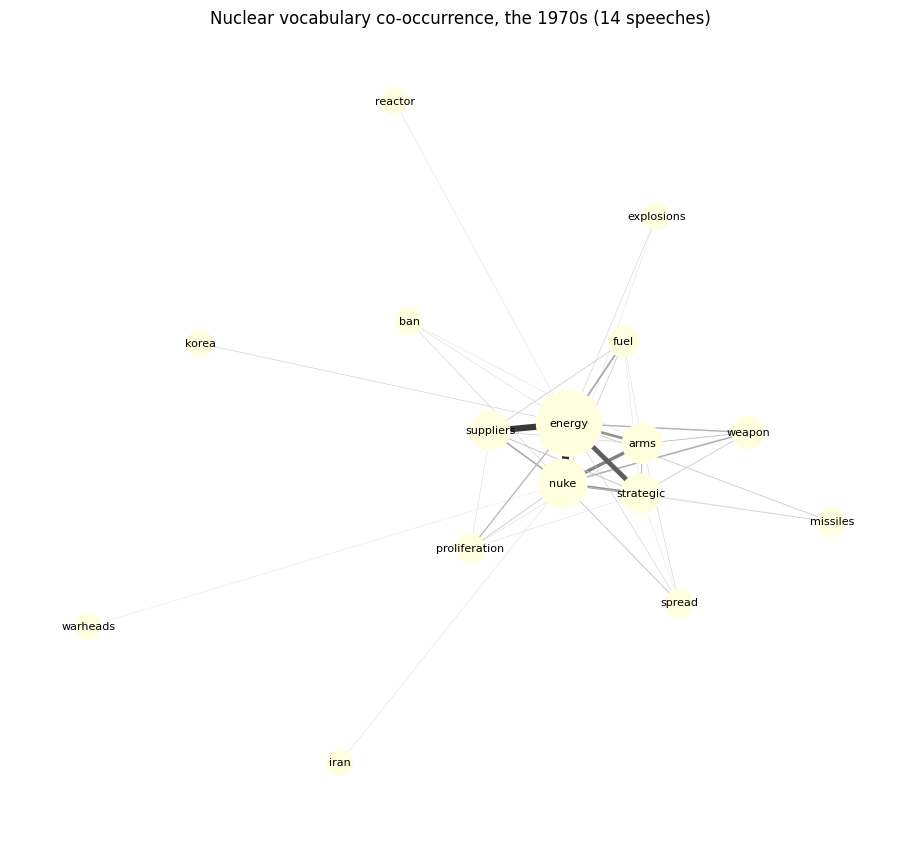

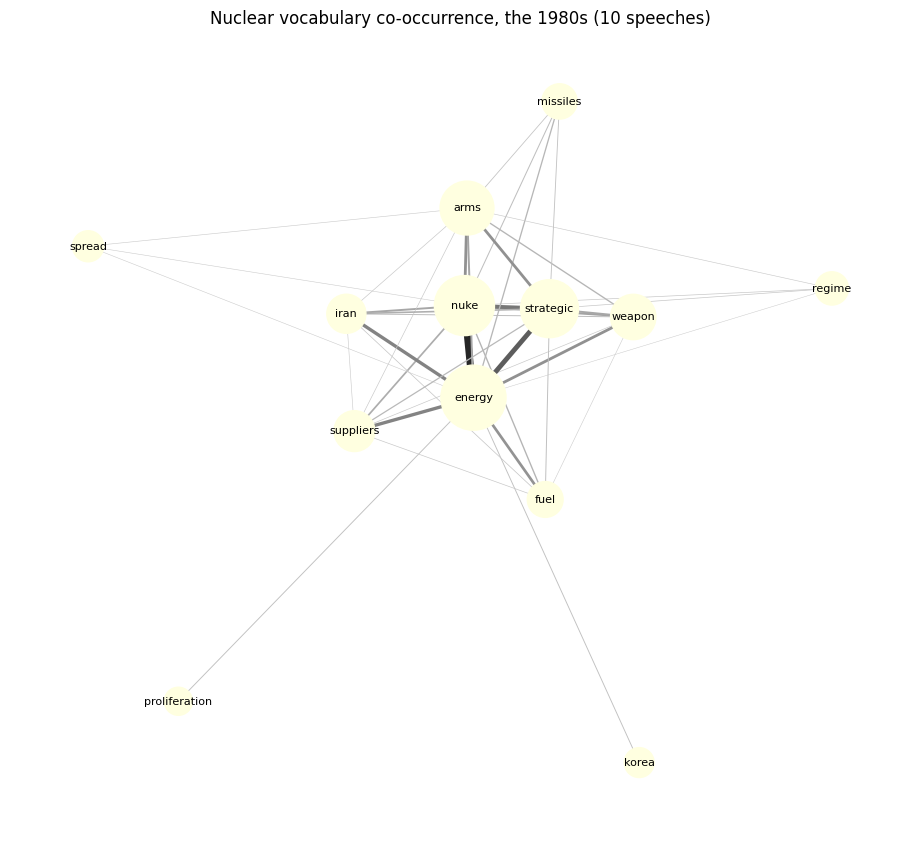

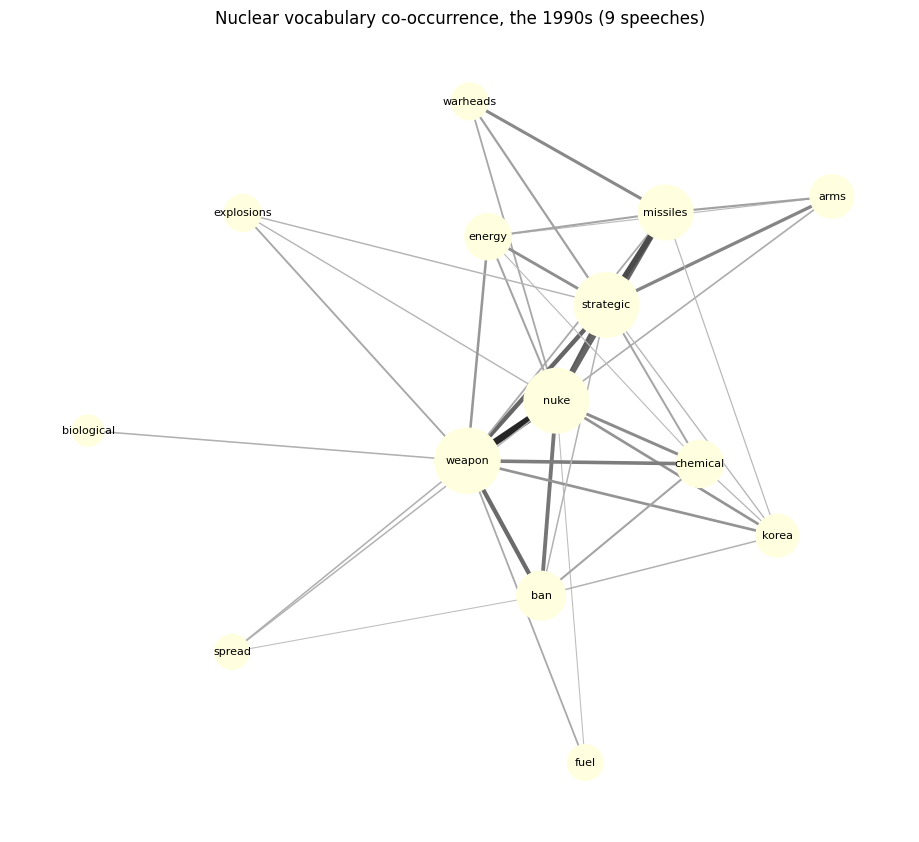

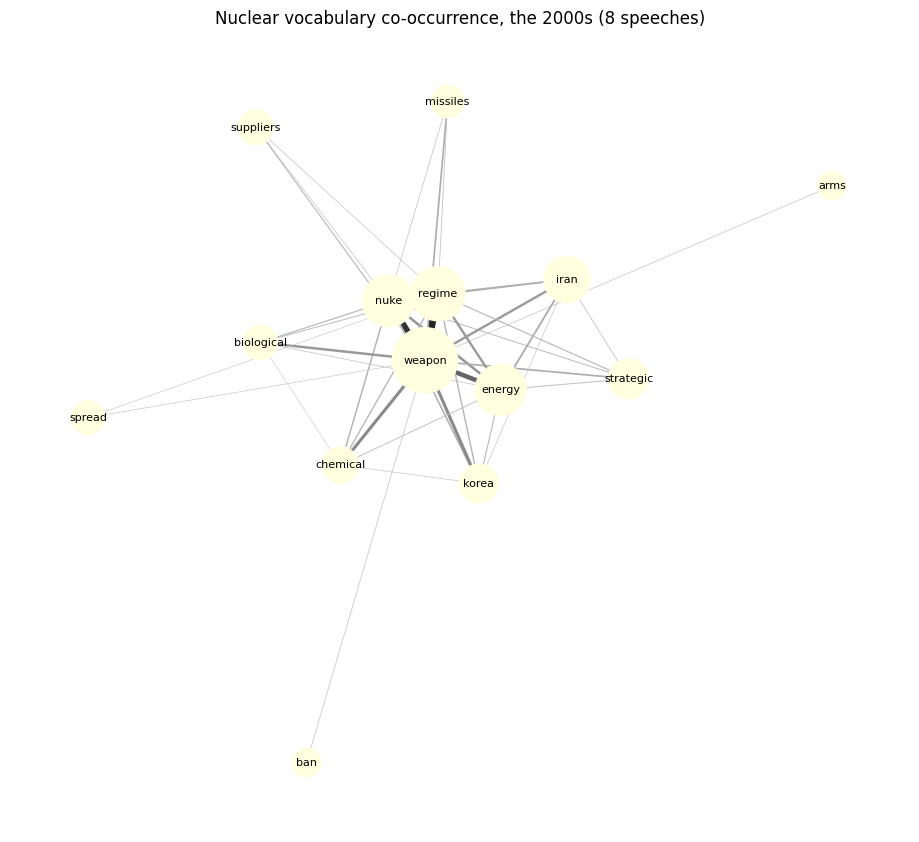

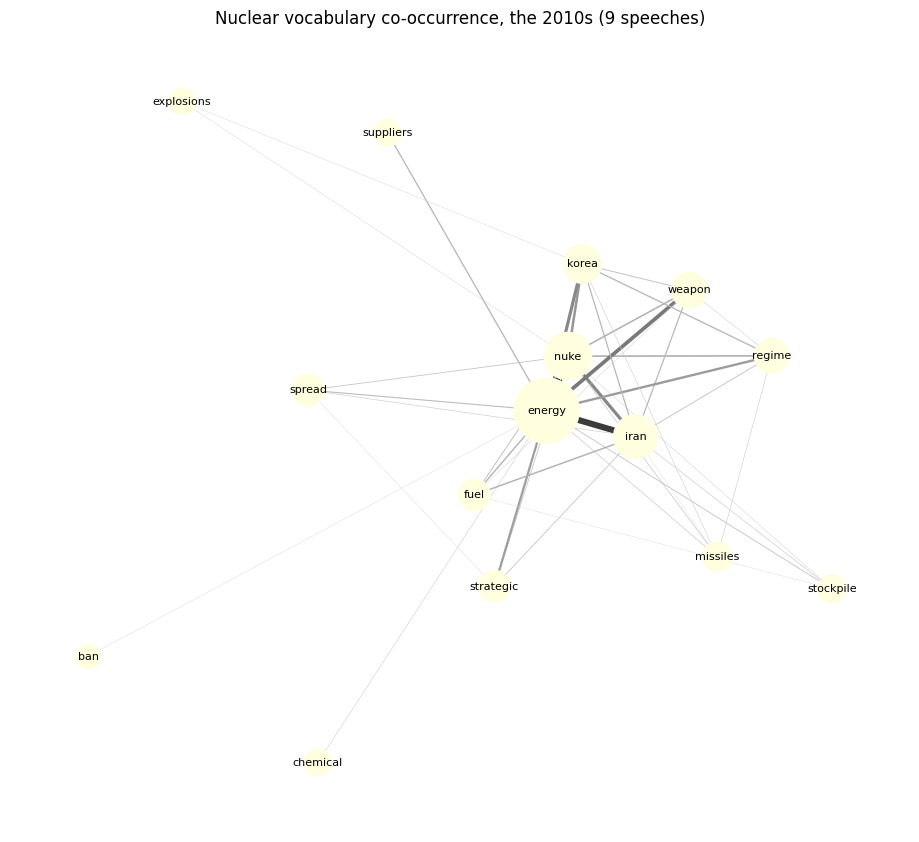

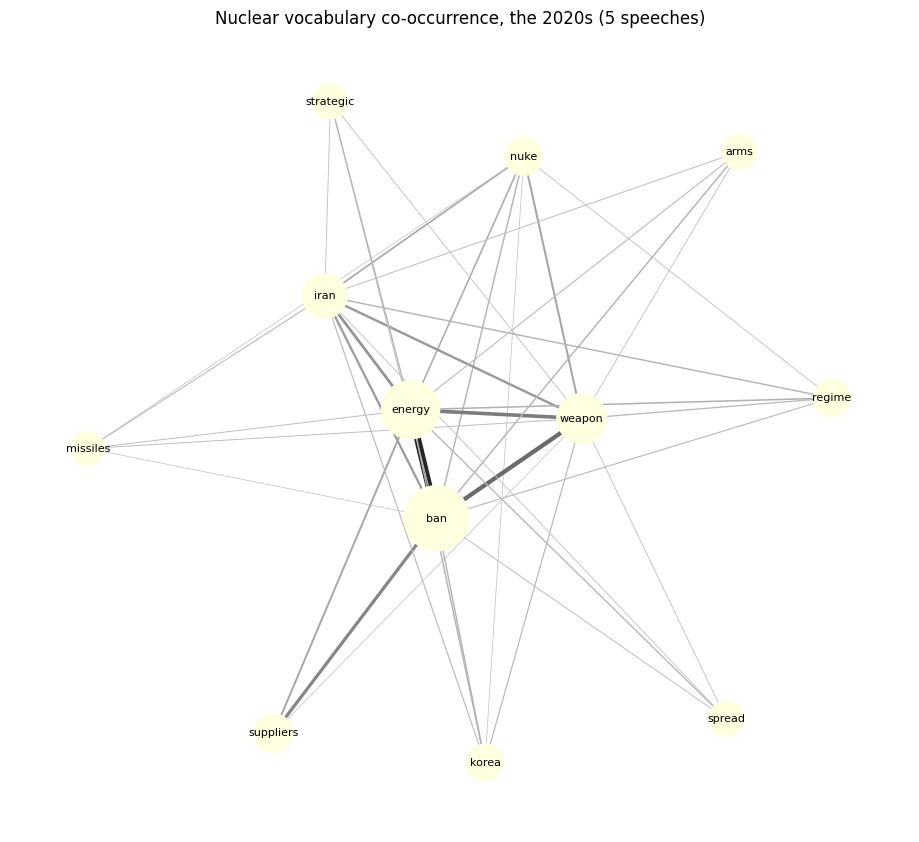

In [23]:
# Every decade from the 1940s to the 2020s. range(1940, 2030, 10) steps by ten.
for decade_start in range(1940, 2030, 10):
    decade_network(decade_start)

## What we've covered

**Python:** `list.extend`; `nltk.collocations` frequency distributions; `while` loops with manual indexing; predicate helper functions; counting with `dict.get(key, 0)`; `scipy.stats.chi2_contingency`; `sorted` with a key function; `range(start, stop, step)`.

**Corpus linguistics:** bigrams and collocations; phrase replacement; keyword windows; keyness with the chi-squared statistic; lexical-dispersion plots; per-decade nuclear-category co-occurrence networks.

## Read more

- **NLTK collocations how-to**: [https://www.nltk.org/howto/collocations.html](https://www.nltk.org/howto/collocations.html).
- **scipy.stats.chi2_contingency**: [https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).
- **Keyness and positive vs negative keywords**: [https://browndw.github.io/textstat_docs/labs/keyness.html](https://browndw.github.io/textstat_docs/labs/keyness.html).
- **NetworkX layouts**: [https://networkx.org/documentation/stable/reference/drawing.html#module-networkx.drawing.layout](https://networkx.org/documentation/stable/reference/drawing.html#module-networkx.drawing.layout).